In [34]:
import numpy as np
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from torch.nn.functional import relu, softmax   

from sklearn.model_selection import train_test_split

from repositories.MediapipeSegmentationRepository import MediapipeSegmentationRepository
from services.PoseClassifier import PoseClassifier
from services.VisualisationService import save_visualized_video

In [35]:
video_folder = "./dataset/videos/handstand"
pose_labels_csv = "./dataset/labels/pose_labels.csv" # videoname, poseFirstFrame1, poseFirstFrame2, .., poseFirstFrameN
skeletons_json = "./dataset/skeletons/handstand_cos_skeletons.json"

In [ ]:
segmentation_repository = MediapipeSegmentationRepository()
video_names = os.listdir(video_folder)

videos_score_data = {}
for video_name in tqdm(video_names):
    videos_score_data[video_name] = {}
    full_video_path = os.path.join(video_folder, video_name)
    frames, feature_tensor, mask = segmentation_repository.process_video_cosine_segments(full_video_path)
    videos_score_data[video_name]["features"] = [[segment[0] for segment in frame] + [segment[1] for segment in frame]
                                                 for frame in feature_tensor.tolist()]
    videos_score_data[video_name]["mask"] = mask.tolist()
    
with open(skeletons_json, 'w') as f:
    json.dump(videos_score_data, f, indent=4)

In [45]:
def process_pose_labels(pose_labels_csv, skeletons_json):
    """
    Process pose labels and skeleton features.
    
    Returns:
        features: list of numpy arrays (num_frames, num_features)
        targets: list of numpy arrays (num_frames, num_poses) - one-hot encoded
        video_names: list of video names
    """
    
    pose_labels = pd.read_csv(pose_labels_csv)
    pose_names = list(pose_labels.columns[1:])  # ['starting', 'swing', 'handstand', 'landing']
    num_poses = len(pose_names)
    
    with open(skeletons_json, 'r') as f:
        videos_score_data = json.load(f)
    
    features = []
    targets = []
    video_names = []
    
    for video_name, video_data in videos_score_data.items():
        cos_angles = np.array(video_data["features"])
        mask = np.array(video_data["mask"])
        num_frames = len(mask)
        
        # Get pose start frames for this video
        video_row = pose_labels[pose_labels["videoname"] == video_name]
        
        if video_row.empty:
            print(f"Warning: {video_name} not found in pose labels, skipping...")
            continue
        
        # Get start frames for each pose
        start_frames = []
        for pose_name in pose_names:
            frame = int(video_row[pose_name].values[0])
            start_frames.append(frame)
        
        # Process start frames (handle -1 cases)
        start_frames = process_start_frames(start_frames, num_frames)
        
        # Generate pose sequence for each frame
        pose_sequence = generate_pose_sequence(start_frames, num_frames, num_poses)
        
        # Find actual start frame (first non -1 original frame, or processed start)
        actual_start = find_actual_start(start_frames)
        
        # Cut from actual start
        cos_angles = cos_angles[actual_start:]
        mask = mask[actual_start:]
        pose_sequence = pose_sequence[actual_start:]
        
        # Apply mask
        valid_indices = mask.astype(bool)
        cos_angles = cos_angles[valid_indices]
        pose_sequence = pose_sequence[valid_indices]
        
        if len(cos_angles) > 0:
            features.append(cos_angles)
            targets.append(pose_sequence)
            video_names.append(video_name)
        else:
            print(f"Warning: {video_name} has no valid frames after masking, skipping...")
    
    return features, targets, video_names, pose_names


def process_start_frames(start_frames, num_frames):
    """
    Handle -1 cases in start frames.
    
    Rules:
    - If -1 is first: discard, start from next valid pose's frame
    - If -1 is after existing pose AND is the last pose: give 20 frames to prev pose
    - If -1 is in the middle: skip that pose (inherit from previous)
    """
    processed = start_frames.copy()
    num_poses = len(processed)
    
    # Find first valid (non -1) index
    first_valid_idx = -1
    for i, frame in enumerate(processed):
        if frame != -1:
            first_valid_idx = i
            break
    
    # If all are -1, return as is (will be handled later)
    if first_valid_idx == -1:
        return processed
    
    # Handle leading -1s: set them to -1 (will be cut later)
    # The actual start will be the first valid frame
    
    # Handle trailing -1s
    last_valid_idx = -1
    for i in range(num_poses - 1, -1, -1):
        if processed[i] != -1:
            last_valid_idx = i
            break
    
    # If last pose is -1 and there's a valid pose before it
    # Give 20 extra frames to last valid pose (handled in sequence generation)
    
    # Handle middle -1s: they will be skipped in sequence generation
    
    return processed


def find_actual_start(start_frames):
    """Find the first valid start frame"""
    for frame in start_frames:
        if frame != -1:
            return frame
    return 0


def generate_pose_sequence(start_frames, num_frames, num_poses):
    """
    Generate one-hot encoded pose sequence for each frame.
    
    Returns:
        pose_sequence: numpy array (num_frames, num_poses)
    """
    pose_sequence = np.zeros((num_frames, num_poses), dtype=np.float32)
    
    # Build list of (start_frame, pose_id) for valid poses
    valid_poses = []
    for pose_id, start_frame in enumerate(start_frames):
        if start_frame != -1:
            valid_poses.append((start_frame, pose_id))
    
    if not valid_poses:
        # No valid poses, return zeros
        return pose_sequence
    
    # Sort by start frame
    valid_poses.sort(key=lambda x: x[0])
    
    # Find last valid pose for -1 handling at end
    last_valid_idx = -1
    for i in range(len(start_frames) - 1, -1, -1):
        if start_frames[i] != -1:
            last_valid_idx = i
            break
    
    # Check if there are trailing -1s
    has_trailing_invalid = last_valid_idx < len(start_frames) - 1
    
    # Fill pose sequence
    for i, (start_frame, pose_id) in enumerate(valid_poses):
        # Determine end frame
        if i < len(valid_poses) - 1:
            # End at next pose's start frame
            end_frame = valid_poses[i + 1][0]
        else:
            # Last valid pose
            if has_trailing_invalid:
                # Give only 20 frames if there are trailing -1s
                end_frame = min(start_frame + 20, num_frames)
            else:
                # Fill to end
                end_frame = num_frames
        
        # Fill one-hot
        pose_sequence[start_frame:end_frame, pose_id] = 1.0
    
    return pose_sequence

In [48]:
features, targets, video_names, pose_names = process_pose_labels(pose_labels_csv, skeletons_json)
print(features[0])
print(targets[0])
x_train, x_test, y_train, y_test = train_test_split(features, targets, test_size=0.2)

[[ 0.78298868  0.97108724  0.78254798 ...  0.99096774  0.
   0.        ]
 [ 0.83227931  0.99021632  0.78998185 ...  0.99131051  0.
   0.        ]
 [ 0.84903153  0.99693939  0.80136081 ...  0.99200348  0.
   0.        ]
 ...
 [ 0.12479421 -0.08970712  0.17836652 ...  0.93178642  0.
   0.        ]
 [ 0.13590615 -0.09791257  0.18088191 ...  0.93107188  0.
   0.        ]
 [ 0.13725287 -0.10026588  0.17177817 ...  0.93008862  0.
   0.        ]]
[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 

In [50]:
num_classes = targets[0].shape[1]
classifier = PoseClassifier(num_classes=num_classes,
                            window_size=24,
                            hidden_size=32,
                            num_layers=4,
                            dropout=0.8,
                            batch_size=256,
                            epochs=200,
                            patience=64,
                            class_names=("Starting", "Swing", "Handstand", "Landing"),
                            device="cuda:0",
                            augment=True,
                            augment_scale_range=(0.97, 1.03))

classifier.fit(x_train, y_train, x_test, y_test)

Creating windows with size 24 and stride 1...
Created 6703 training windows from 57 sequences
Created 1819 validation windows from 15 sequences


Training:  38%|███▊      | 76/200 [00:30<00:49,  2.52it/s, Loss: 0.6766, Acc: 0.7370 | Val: 0.9843, 0.7587]


Early stopping at epoch 77


<Axes: >

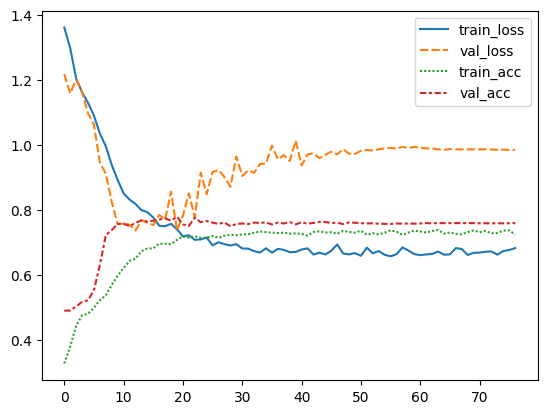

In [51]:
sns.lineplot(classifier.history)

In [13]:

torch.save(classifier.model, './model_weights/gruClassifier7821.pth')

In [31]:
# Test
segmentation_repository = MediapipeSegmentationRepository()

test_video_path = "./dataset/videos/test/video_2026-01-16_10-20-32.mp4"
frames, feature_tensor, mask = segmentation_repository.process_video_cosine_segments(test_video_path)
videos_score_data = [[segment[0] for segment in frame] + [segment[1] for segment in frame]
                      for frame in feature_tensor[mask].tolist()]


predictions, probabilities = classifier.predict_frames([videos_score_data])

I0000 00:00:1768581106.088382   71759 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1768581106.099410   76501 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1768581106.334053   76490 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768581107.527239   76493 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [33]:
class_names = ("Starting", "Swing", "Handstand", "Landing")
frame_annotations = []
for pred, proba in zip(predictions[0], probabilities[0]):
    frame_annotations.append({
        "label": f"{class_names[pred]}: {proba[pred]:.2%}"
    })


save_visualized_video("./dataset/videos/test/test.mp4", 
                      frames, 
                      test_video_path,
                      frame_annotations=frame_annotations)